# 02 – Business Intelligence: Descriptive Metrics

This notebook provides baseline descriptive summaries of manufacturing job postings
using the standardized dataset produced in Notebook 01.

The purpose is to establish visibility into hiring demand before introducing
any modeling or decision-support assumptions.

## Load Clean Dataset

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(".../Research Grant Project - Manufacturing Jobs - Manufacturing Information.csv")
df = pd.read_csv(DATA_PATH)

df.shape, df.head()

Matplotlib is building the font cache; this may take a moment.


((388, 8),
   employer_name                                          job_title  \
 0        Boeing     Yocto Linux Software Engineer (Virtual) Senior   
 1        Dexcom                    Sr Process Development Engineer   
 2        Dexcom  Director of Medical Device Engineering - Senso...   
 3        Dexcom  Sr Sales Operations Analyst (Incentive Compens...   
 4        Dexcom            Manager Process Development Engineering   
 
                   salary_raw  salary_min  salary_max platform  \
 0  $123,250.00 - $192,050.00    123250.0    192050.0  Website   
 1   $91,400.00 - $152,300.00     91400.0    152300.0  Website   
 2  $190,100.00 - $316,800.00    190100.0    316800.0  Website   
 3   $87,000.00 - $145,000.00     87000.0    145000.0  Website   
 4  $116,600.00 - $194,400.00    116600.0    194400.0  Website   
 
                                        position_link  \
 0  https://jobs.boeing.com/job/mesa/yocto-linux-m...   
 1  https://careers.dexcom.com/careers?domain=dex

## Employer Demand Overview


In [3]:
employer_counts = (
    df["employer_name"]
    .value_counts()
    .rename("posting_count")
    .reset_index()
    .rename(columns={"index": "employer_name"})
)

employer_counts.head(10)

,employer_name,posting_count
0,Boeing,129
1,Dexcom,66
2,Tesla,54
3,ASML,34
4,Procter & Gamble,22
5,GrayMatter Robotics,16
6,ResMed,16
7,Oldcastle Infrastructure,11
8,Frito-Lay,8
9,"California Dairies, Inc.",8


In [ ]:
employer_counts.to_csv(".../employer_posting_counts.csv", index=False)


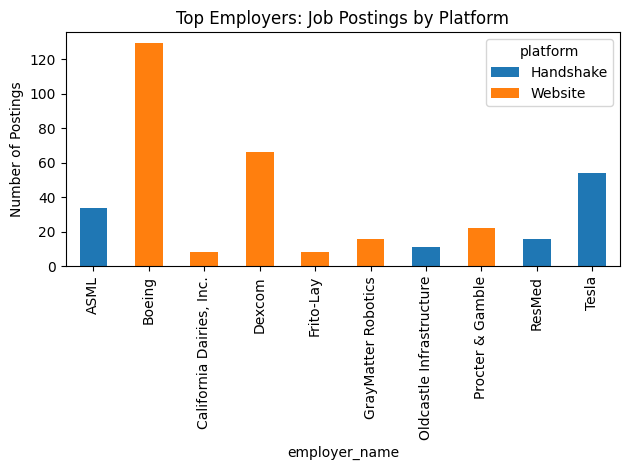

In [15]:
top_employers = employer_counts.head(10)["employer_name"]

platform_by_employer = (
    df[df["employer_name"].isin(top_employers)]
    .groupby(["employer_name", "platform"])
    .size()
    .unstack(fill_value=0)
)

platform_by_employer.plot(kind="bar", stacked=True)
plt.ylabel("Number of Postings")
plt.title("Top Employers: Job Postings by Platform")
plt.tight_layout()
plt.show()



## Job Posting Platforms

In [13]:
platform_counts = (
    df["platform"]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "platform"})
)

platform_counts["percent"] = (
    platform_counts["count"] / platform_counts["count"].sum() * 100
).round(1)

platform_counts



,platform,count,percent
0,Website,266,68.6
1,Handshake,122,31.4


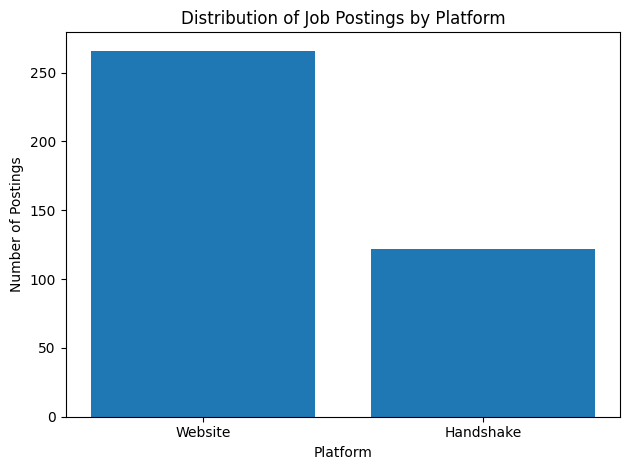

In [8]:
plt.figure()
plt.bar(platform_counts["platform"], platform_counts["count"])
plt.xlabel("Platform")
plt.ylabel("Number of Postings")
plt.title("Distribution of Job Postings by Platform")
plt.tight_layout()
plt.show()


Handshake postings are treated as student-facing opportunities,
while Website postings represent external employer hiring channels.

## Job Title Frequency


In [9]:
job_title_counts = (
    df["job_title"]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "job_title"})
)

job_title_counts.head(15)


,job_title,count
0,Maintenance Supervisor,2
1,Continuous Improvement Manager,2
2,Yocto Linux Software Engineer (Virtual) Senior,1
3,Sr Process Development Engineer,1
4,Director of Medical Device Engineering - Senso...,1
5,Sr Sales Operations Analyst (Incentive Compens...,1
6,Manager Process Development Engineering,1
7,Financial Analyst - Commercial,1
8,Staff Process Engineer,1
9,Senior Systems Engineer - Configuration Manage...,1


## Salary Information Coverage

In [11]:
salary_coverage = pd.DataFrame({
    "field": ["salary_min", "salary_max"],
    "percent_non_null": [
        df["salary_min"].notna().mean() * 100,
        df["salary_max"].notna().mean() * 100
    ]
})

salary_coverage


,field,percent_non_null
0,salary_min,62.113402
1,salary_max,62.113402


## BI Summary

Key descriptive takeaways from this dataset:

- Manufacturing hiring demand is concentrated among a small number of employers.
- Job postings are split between student-facing platforms and external career sites.
- Job titles exhibit high variability, motivating downstream role abstraction.
- Salary information is inconsistently available and excluded from modeling.

These findings motivate the role and pipeline abstractions introduced in the next notebook.